# Icosahedral Global Graph - Internals of `weather-model-graphs`

This notebook explains *how* `weather-model-graphs` constructs icosahedral graphs under the hood.

1. **Mesh generation with `trimesh`** - icosahedral subdivision and coordinate representation
2. **3-D mesh visualisation** - inspecting the sphere geometry directly
3. **Performance and scaling** - how node/face counts grow with subdivision level
4. **Face-adjacent connectivity** - every node has exactly 5 or 6 neighbours
5. **Containing-triangle M2G** - barycentric interpolation from grid point to mesh

Familiarity with the user-facing API is assumed; see `icosahedral_global_graph_usage.ipynb` for that.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pyproj

In [2]:
from weather_model_graphs.create.mesh.layouts.icosahedral import (
    create_hierarchy_of_icosahedral_meshes,
    generate_icosahedral_mesh,
    connect_grid_to_mesh,
    lat_lon_to_cartesian,
    cartesian_to_lat_lon,
    barycentric_coordinates,
)

## Setup: sample grid and mesh

We reuse a 2.5deg global grid and a level-3 mesh throughout this notebook.

In [3]:
resolution = 2.5
lats = np.arange(-90, 90.1, resolution)
lons = np.arange(-180, 180.1, resolution)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing="ij")
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])

mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions=3)
finest_vertices, finest_faces = mesh_list[-1]
g2m_edges = connect_grid_to_mesh(
    grid_lat_lon, finest_vertices, finest_faces, radius_factor=0.6
)

print(f"Grid: {len(grid_lat_lon)} points")
print(f"Mesh level 3: {len(finest_vertices)} vertices, {len(finest_faces)} faces")
print(f"G2M edges: {g2m_edges.shape[1]}")

Grid: 10585 points
Mesh level 3: 642 vertices, 1280 faces
G2M edges: 16617


## 1. 3-D Mesh Visualisation

Plotting the mesh in Cartesian space makes it easy to verify that vertices sit on the unit sphere and that subdivision is uniform.

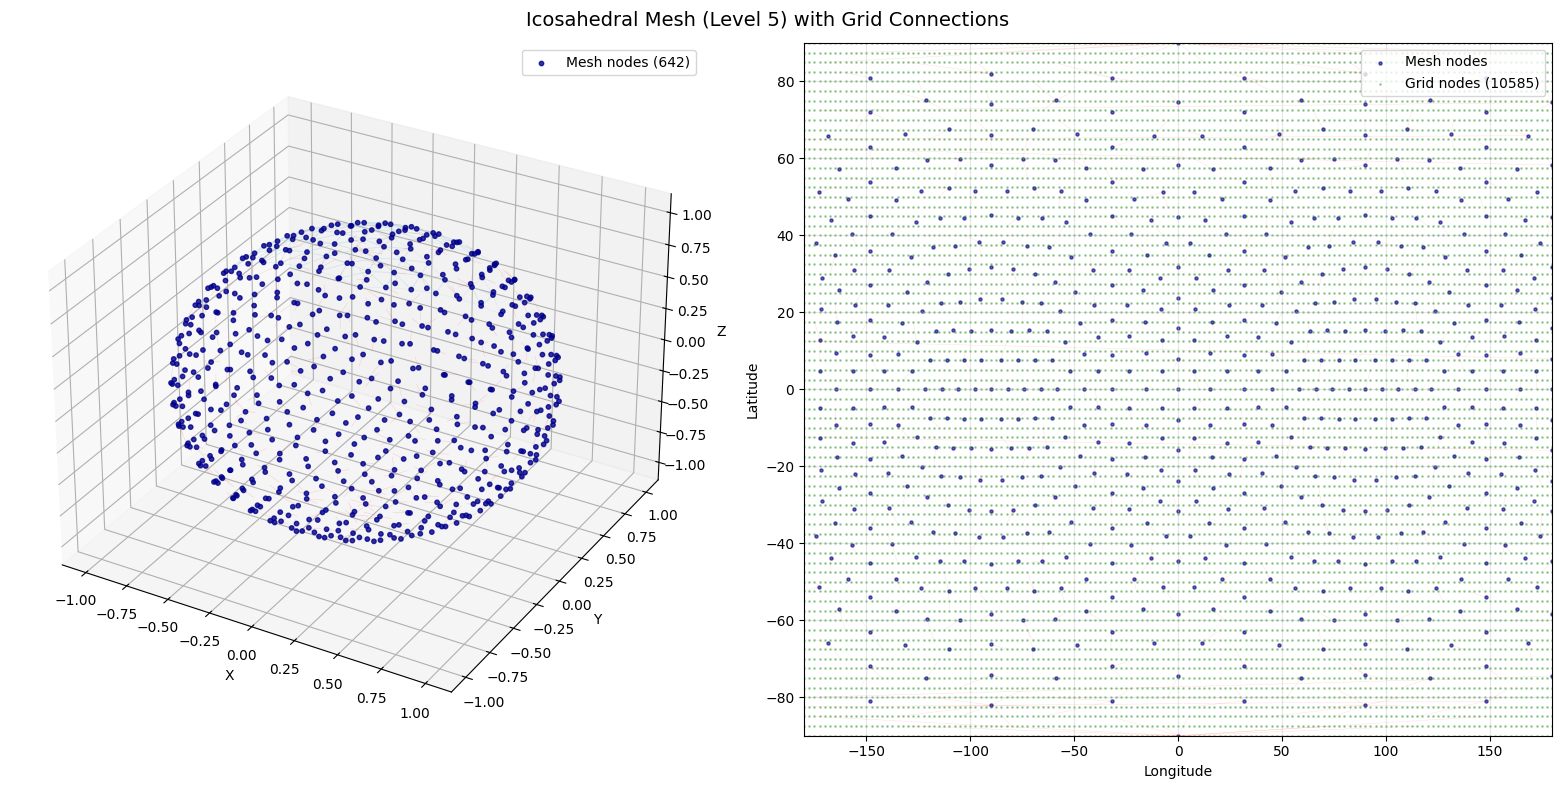

In [8]:
def plot_icosahedral_graph(
    vertices,
    faces,
    g2m_edges=None,
    grid_lat_lon=None,
    title=None,
    max_edges_to_plot=500,
):
    """Plot icosahedral mesh with optional grid connections."""
    fig = plt.figure(figsize=(16, 8))

    # 3D Plot
    ax1 = fig.add_subplot(121, projection="3d")

    # Plot mesh edges
    for face in faces[:100]:  # Plot subset for clarity
        for i, j in [(0, 1), (1, 2), (2, 0)]:
            ax1.plot3D(
                *zip(vertices[face[i]], vertices[face[j]]),
                color="lightblue",
                alpha=0.3,
                linewidth=0.5,
            )

    # Plot mesh nodes
    ax1.scatter(
        vertices[:, 0],
        vertices[:, 1],
        vertices[:, 2],
        c="darkblue",
        s=10,
        label=f"Mesh nodes ({len(vertices)})",
        alpha=0.8,
    )

    # Plot grid-to-mesh connections if provided
    if g2m_edges is not None and grid_lat_lon is not None:
        # Sample connections for clarity
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_cart = lat_lon_to_cartesian(
                np.array([grid_lat_lon[grid_idx, 0]]),
                np.array([grid_lat_lon[grid_idx, 1]]),
            )[0]
            ax1.plot3D(
                *zip(grid_cart, vertices[mesh_idx]),
                color="red",
                alpha=0.2,
                linewidth=0.3,
            )

    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.legend(loc="upper right")

    # 2D Projection
    ax2 = fig.add_subplot(122)

    # Convert mesh vertices to lat/lon
    mesh_lat_lon = cartesian_to_lat_lon(vertices)

    # Plot mesh nodes
    ax2.scatter(
        mesh_lat_lon[:, 1],
        mesh_lat_lon[:, 0],
        c="darkblue",
        s=5,
        label="Mesh nodes",
        alpha=0.6,
    )

    # Plot grid nodes if provided
    if grid_lat_lon is not None:
        ax2.scatter(
            grid_lat_lon[:, 1],
            grid_lat_lon[:, 0],
            c="green",
            s=1,
            label=f"Grid nodes ({len(grid_lat_lon)})",
            alpha=0.3,
        )

    # Plot connections in 2D
    if g2m_edges is not None and grid_lat_lon is not None:
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_lon, grid_lat = grid_lat_lon[grid_idx, 1], grid_lat_lon[grid_idx, 0]
            mesh_lon, mesh_lat = mesh_lat_lon[mesh_idx, 1], mesh_lat_lon[mesh_idx, 0]
            ax2.plot(
                [grid_lon, mesh_lon],
                [grid_lat, mesh_lat],
                color="red",
                alpha=0.15,
                linewidth=0.3,
            )

    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    ax2.set_xlim(-180, 180)
    ax2.set_ylim(-90, 90)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper right")

    if title:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    return fig, (ax1, ax2)


max_subdivisions = 5

# Plot the finest mesh with grid connections
fig, axes = plot_icosahedral_graph(
    finest_vertices,
    finest_faces,
    g2m_edges,
    grid_lat_lon,
    title=f"Icosahedral Mesh (Level {max_subdivisions}) with Grid Connections",
)
plt.show()

## 2. Performance and Scaling and Scaling

Let's examine how the mesh size scales with subdivision level.

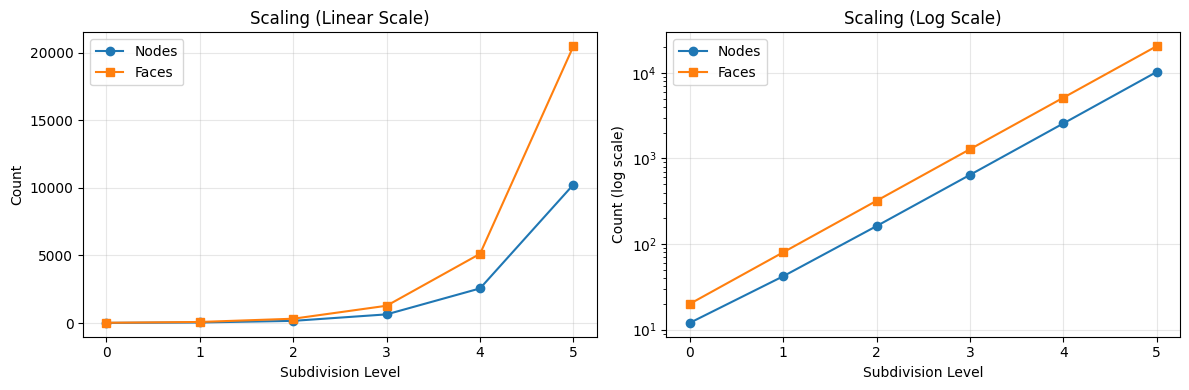


Growth rate:
Level 0 -> 1: 3.50x (theoretical: 4x)
Level 1 -> 2: 3.86x (theoretical: 4x)
Level 2 -> 3: 3.96x (theoretical: 4x)
Level 3 -> 4: 3.99x (theoretical: 4x)
Level 4 -> 5: 4.00x (theoretical: 4x)


In [ ]:
# Analyze scaling behavior
subdivisions = np.arange(0, 6)
node_counts = []
face_counts = []

for s in subdivisions:
    v, f = generate_icosahedral_mesh(refinement_level=s)
    node_counts.append(len(v))
    face_counts.append(len(f))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax1.plot(subdivisions, node_counts, "o-", label="Nodes")
ax1.plot(subdivisions, face_counts, "s-", label="Faces")
ax1.set_xlabel("Subdivision Level")
ax1.set_ylabel("Count")
ax1.set_title("Scaling (Linear Scale)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(subdivisions, node_counts, "o-", label="Nodes")
ax2.semilogy(subdivisions, face_counts, "s-", label="Faces")
ax2.set_xlabel("Subdivision Level")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Scaling (Log Scale)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGrowth rate:")
for i in range(1, len(subdivisions)):
    ratio = node_counts[i] / node_counts[i - 1]
    print(f"Level {i-1} -> {i}: {ratio:.2f}x (theoretical: 4x)")

## 3. Face-Adjacent Connectivity-Adjacent Connectivity

Every node connects to exactly 5 or 6 face-adjacent neighbours — 5 at the 12 original icosahedron vertices, 6 everywhere else. Connectivity is fully determined by the triangulation faces, no pattern kwarg needed.

In [7]:
import plotly.graph_objects as go

vertices, faces = generate_icosahedral_mesh(refinement_level=1)
lat_lon = cartesian_to_lat_lon(vertices)
lat, lon = lat_lon[:, 0], lat_lon[:, 1]

edges = set()
for f in faces:
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        edges.add((min(f[i], f[j]), max(f[i], f[j])))

degree = np.zeros(len(vertices), dtype=int)
for e in edges:
    degree[e[0]] += 1
    degree[e[1]] += 1

edge_lons, edge_lats = [], []
for e in edges:
    lo = [lon[e[0]], lon[e[1]]]
    la = [lat[e[0]], lat[e[1]]]
    if abs(lo[1] - lo[0]) < 180:
        edge_lons += [lo[0], lo[1], None]
        edge_lats += [la[0], la[1], None]

highlight_idx = next(
    i for i in range(len(vertices)) if degree[i] == 6 and abs(lat[i]) < 20
)
neighbours = [
    e[1] if e[0] == highlight_idx else e[0] for e in edges if highlight_idx in e
]

hl_lons, hl_lats = [], []
for n in neighbours:
    if abs(lon[n] - lon[highlight_idx]) < 180:
        hl_lons += [lon[highlight_idx], lon[n], None]
        hl_lats += [lat[highlight_idx], lat[n], None]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=edge_lons,
        y=edge_lats,
        mode="lines",
        line=dict(color="steelblue", width=1),
        opacity=0.5,
        name="Face-adjacent edge",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=lon[degree == 6],
        y=lat[degree == 6],
        mode="markers",
        marker=dict(size=9, color="cornflowerblue", line=dict(color="white", width=1)),
        name="6 neighbours (regular)",
    )
)
fig.add_trace(
    go.Scatter(
        x=lon[degree == 5],
        y=lat[degree == 5],
        mode="markers",
        marker=dict(size=9, color="tomato", line=dict(color="white", width=1)),
        name="5 neighbours (icosahedral vertex)",
    )
)
fig.add_trace(
    go.Scatter(
        x=hl_lons,
        y=hl_lats,
        mode="lines",
        line=dict(color="gold", width=3),
        name=f"Example node: {degree[highlight_idx]} face-adjacent neighbours",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=[lon[highlight_idx]],
        y=[lat[highlight_idx]],
        mode="markers",
        marker=dict(size=15, color="gold", line=dict(color="black", width=2)),
        name="Example node",
    )
)
fig.update_layout(
    title="Icosahedral Mesh - Face-adjacent Connectivity (Refinement Level 1)",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    xaxis=dict(range=[-185, 185]),
    yaxis=dict(range=[-95, 95]),
    width=1100,
    height=620,
)
fig.show()

## 4. Containing Triangle M2G Triangle M2G

Each grid point connects to the 3 vertices of its containing mesh triangle. Edge weights are barycentric coordinates — they sum to 1 and line thickness is proportional to weight.

In [ ]:
from scipy.spatial import cKDTree

vertices, faces = generate_icosahedral_mesh(refinement_level=2)
lat_lon = cartesian_to_lat_lon(vertices)
lat, lon = lat_lon[:, 0], lat_lon[:, 1]

target_lat, target_lon = 20.0, 10.0
target_xyz = lat_lon_to_cartesian(np.array([target_lat]), np.array([target_lon]))

face_centroids = vertices[faces].mean(axis=1)
face_centroids /= np.linalg.norm(face_centroids, axis=1, keepdims=True)
tree = cKDTree(face_centroids)

_, near = tree.query(target_xyz, k=8)
containing_face, bary = None, None
for fi in near[0]:
    v1, v2, v3 = faces[fi]
    w = barycentric_coordinates(target_xyz[0], vertices[v1], vertices[v2], vertices[v3])
    if w is not None and w.min() >= -1e-6:
        containing_face, bary = fi, w / w.sum()
        break

if containing_face is None:
    containing_face = near[0][0]
    v1, v2, v3 = faces[containing_face]
    bary = barycentric_coordinates(
        target_xyz[0], vertices[v1], vertices[v2], vertices[v3]
    )
    bary = np.clip(bary, 0, None)
    bary /= bary.sum()

tri_verts = list(faces[containing_face])
tri_lats, tri_lons = lat[tri_verts], lon[tri_verts]

_, nearby_faces = tree.query(face_centroids[containing_face : containing_face + 1], k=7)
context_nodes = set()
for fi in nearby_faces[0]:
    for ni in faces[fi]:
        context_nodes.add(ni)
context_nodes -= set(tri_verts)

fig = go.Figure()
for fi in nearby_faces[0]:
    if fi == containing_face:
        continue
    fv = faces[fi]
    flats, flons = lat[fv], lon[fv]
    if np.max(flons) - np.min(flons) > 90:
        continue
    fig.add_trace(
        go.Scatter(
            x=list(flons) + [flons[0]],
            y=list(flats) + [flats[0]],
            mode="lines",
            line=dict(color="lightsteelblue", width=1),
            opacity=0.6,
            showlegend=False,
            hoverinfo="skip",
        )
    )

fig.add_trace(
    go.Scatter(
        x=list(tri_lons) + [tri_lons[0]],
        y=list(tri_lats) + [tri_lats[0]],
        mode="lines",
        fill="toself",
        fillcolor="rgba(100,149,237,0.15)",
        line=dict(color="cornflowerblue", width=2.5),
        name="Containing triangle",
    )
)
for vi, (node_idx, w) in enumerate(zip(tri_verts, bary)):
    fig.add_trace(
        go.Scatter(
            x=[target_lon, lon[node_idx]],
            y=[target_lat, lat[node_idx]],
            mode="lines",
            line=dict(color="tomato", width=1.5 + 5.0 * float(w)),
            name=f"w{vi+1} = {w:.3f}",
        )
    )
fig.add_trace(
    go.Scatter(
        x=lon[list(context_nodes)],
        y=lat[list(context_nodes)],
        mode="markers",
        marker=dict(size=7, color="lightsteelblue", line=dict(color="white", width=1)),
        name="Other mesh nodes",
    )
)
fig.add_trace(
    go.Scatter(
        x=tri_lons,
        y=tri_lats,
        mode="markers+text",
        marker=dict(size=14, color="cornflowerblue", line=dict(color="white", width=2)),
        text=[
            f"v1 (w={bary[0]:.3f})",
            f"v2 (w={bary[1]:.3f})",
            f"v3 (w={bary[2]:.3f})",
        ],
        textposition=["top left", "top right", "bottom center"],
        textfont=dict(size=12),
        name="Triangle vertices",
    )
)
fig.add_trace(
    go.Scatter(
        x=[target_lon],
        y=[target_lat],
        mode="markers+text",
        marker=dict(
            size=14, color="tomato", symbol="square", line=dict(color="black", width=2)
        ),
        text=["Grid point"],
        textposition="middle right",
        name="Grid point",
    )
)
pad = 12
fig.update_layout(
    title="Containing Triangle M2G - Single Grid Point",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    xaxis=dict(range=[target_lon - pad, target_lon + pad]),
    yaxis=dict(range=[target_lat - pad, target_lat + pad]),
    width=800,
    height=700,
)